So Here we have data called economic_index.csv
1. we use 'interest_rate' and 'unemployment_rate' two features and then we can use those for predicting the "index_price"...


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# reading the data 
df_index = pd.read_csv('economic_index.csv')
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [ ]:
# droping unnecessory column
df_index.drop(columns=["Unnamed: 0", "year", "month"], axis=1, inplace=True)

In [9]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [16]:
df_index.shape

(24, 3)

In [17]:
# check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

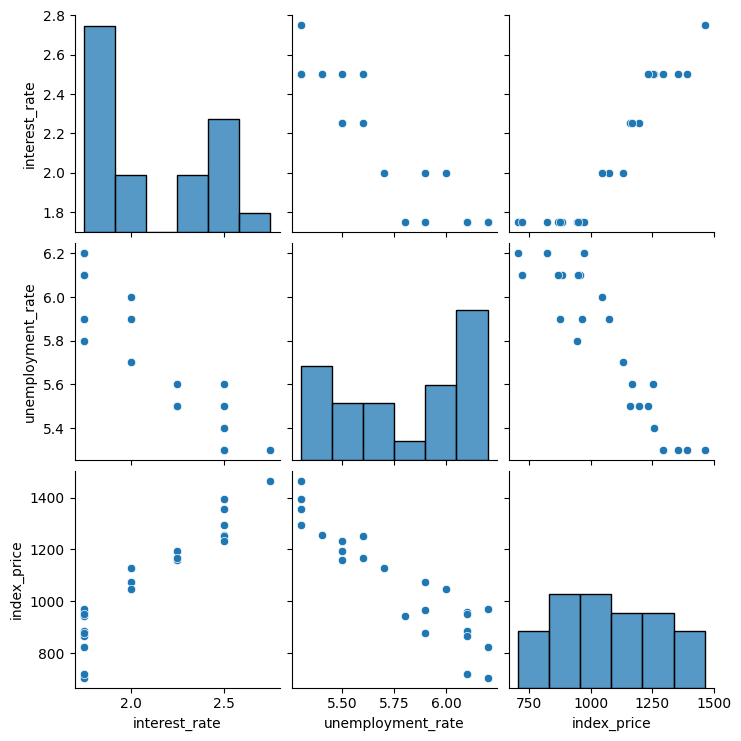

In [18]:
# Visulization
import seaborn as sns
sns.pairplot(df_index)

In [19]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

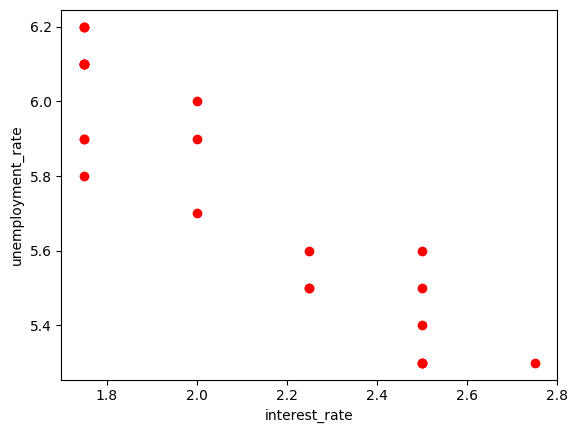

In [22]:
# Visulization of datapoint more closely
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='red') 
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')

In [23]:
# Getting my indepenmdant and dependant feature

# X=df_index[['interest_rate'], ['unemployment_rate']] # unother method to write this below
X = df_index.iloc[:, :-1]   # It means all the columns excepting the last one
y = df_index.iloc[:, -1]

In [24]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [25]:
# train - test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
 

<Axes: xlabel='interest_rate', ylabel='index_price'>

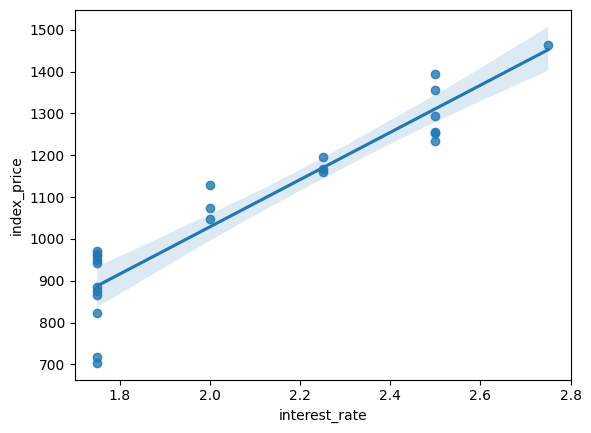

In [31]:
# Visulization of regplot

import seaborn as sns

sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

# You can see in the output the error is quite less; see the amazing regression line

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

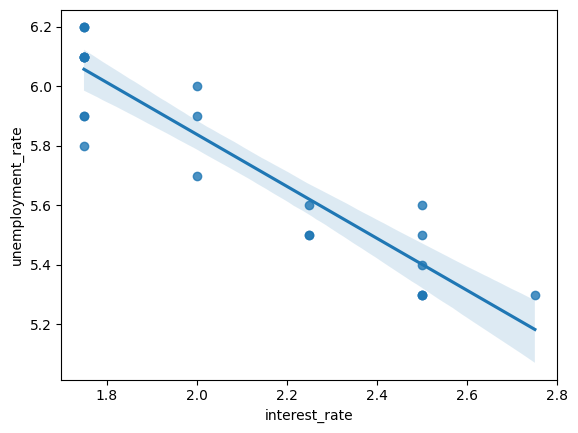

In [29]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

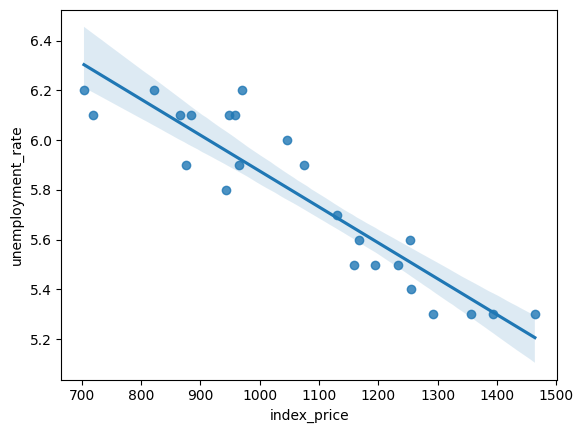

In [30]:
sns.regplot(x=df_index['index_price'], y=df_index['unemployment_rate'])

In [32]:
# Standardization

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [34]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

In [35]:
regression.fit(X_train, y_train)

LinearRegression()

## Cross Validation

<img src='img.png'>

In [ ]:
# Lets Understand Cross-Validation:

from sklearn.model_selection import cross_val_score

validation_score = cross_val_score(estimator=regression, 
                                   X=X_train, 
                                   y=y_train, 
                                   scoring='neg_mean_squared_error',   # you can go the official website and see diff. scoring
                                   cv=3
                                   )

In [39]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [40]:
np.mean(validation_score)

-5914.828180162386

In [41]:
# Predicrtion

y_pred = regression.predict(X_test)

In [42]:
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [43]:
# Performance metrix
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [45]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

5793.762887712569
59.935781523235484
76.11677139574805


In [46]:
# R_square & Adjusted R_square
from sklearn.metrics import r2_score

In [47]:
score = r2_score(y_test, y_pred)
print(score)

0.8278978091457145


In [48]:
# Adjusted R_square
1 - ((1-score)*(len(y_test-1)) / (len(y_test)-X_test.shape[1]-1))

0.6557956182914291

## Assumptions


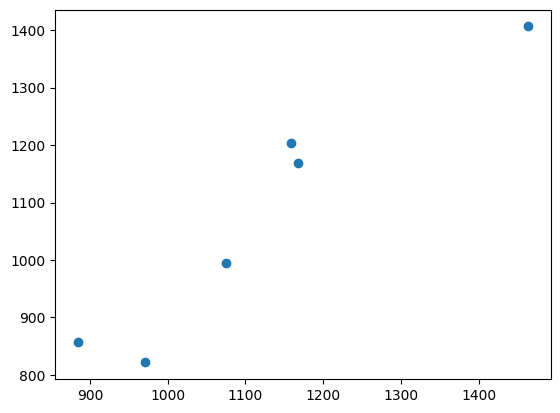

In [ ]:
plt.scatter(y_test,y_pred)  # In the output u can see that both are linearly related so model performing well.

In [50]:
# Residual
residual = y_test - y_pred
print(residual)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


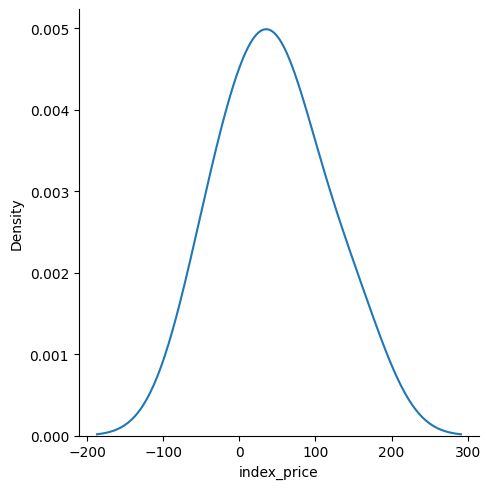

In [54]:
# Plot this residual
sns.displot(residual, kind='kde')

# If in the output you are getting the normal diss. that means the model you have created is good.

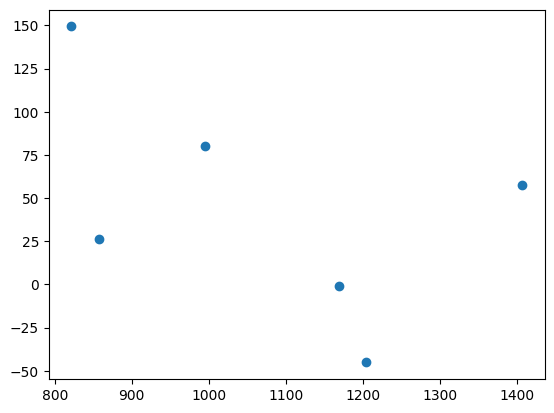

In [56]:
# Scatter Plot with respect to residual and prediction

plt.scatter(y_pred, residual)

# If the scatter plot output is like data seprated everyware uniformaly and not showing any pattern then there is no such error.  

In [60]:
# OLS Model

import statsmodels.api as sm

In [61]:
model = sm.OLS(y_train, X_train).fit()

In [62]:
prediction = model.predict(X_test)
print(prediction)

[ 150.78325954 -231.79392541  353.06855924 -195.73554836  -58.53452146
  114.72488249]


In [63]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 04 May 2026   Prob (F-statistic):                       0.754
Time:                        22:21:17   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\Users\Krish\AppData\Roaming\Python\Python311\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


In [64]:
regression.coef_

array([  88.27275507, -116.25716066])

In [65]:
regression.intercept_

1053.4444444444443